In [140]:
import math
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd

In [ ]:
PLACE = "California, United States"
NETWORK_TYPE = "drive"
RANDOM_SEED = 42
SIMULATION_STEPS = 90
CYCLE_TIME = 60
MIN_GREEN = 15
MAX_GREEN = 45
ARRIVAL_RATE = 18
NUM_OD_PAIRS = 40
NUM_TRIALS = 20
BETWEENNESS_K = 80
ALPHA = 0.75
BETA = 0.25

rng = np.random.default_rng(RANDOM_SEED)
ox.settings.use_cache = True

In [142]:
def parse_numeric(value, default):
    if value is None:
        return default
    if isinstance(value, list):
        value = value[0]
    if isinstance(value, str):
        digits = "".join(ch for ch in value if ch.isdigit() or ch == ".")
        return float(digits) if digits else default
    return float(value)


def collapse_multidigraph(multigraph):
    graph = nx.DiGraph()
    for node, data in multigraph.nodes(data=True):
        graph.add_node(node, **data)

    for u, v, data in multigraph.edges(data=True):
        edge_data = dict(data)
        edge_data["length"] = float(edge_data.get("length", 1.0))
        if graph.has_edge(u, v):
            if edge_data["length"] < graph[u][v]["length"]:
                graph[u][v].update(edge_data)
        else:
            graph.add_edge(u, v, **edge_data)

    return graph

In [143]:
raw_graph = ox.graph_from_place(PLACE, network_type=NETWORK_TYPE, simplify=True)
largest_component = max(nx.strongly_connected_components(raw_graph), key=len)
raw_graph = raw_graph.subgraph(largest_component).copy()

G = collapse_multidigraph(raw_graph)
G.graph["crs"] = raw_graph.graph.get("crs")

for u, v, data in G.edges(data=True):
    length = float(data.get("length", 1.0))
    speed_kph = parse_numeric(data.get("maxspeed"), 35.0)
    lanes = max(1, int(round(parse_numeric(data.get("lanes"), 1.0))))
    travel_time = length / max(speed_kph * 1000 / 3600, 1.0)

    data["length"] = length
    data["speed_kph"] = speed_kph
    data["lanes"] = lanes
    data["travel_time"] = travel_time
    data["capacity_per_cycle"] = max(1, int(lanes * 8))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 130283
Edges: 300324


In [144]:
k_value = min(BETWEENNESS_K, max(10, G.number_of_nodes() - 1))
betweenness = nx.betweenness_centrality(
    G,
    k=k_value,
    normalized=True,
    weight="travel_time",
    seed=RANDOM_SEED,
    endpoints=False,
)

max_bc = max(betweenness.values()) if betweenness else 1.0
node_importance = {
    node: (value / max_bc if max_bc else 0.0)
    for node, value in betweenness.items()
}
nx.set_node_attributes(G, node_importance, "betweenness_norm")

candidate_nodes = [
    node
    for node in G.nodes()
    if G.in_degree(node) > 0 and G.out_degree(node) > 0
]

print(f"Candidate intersections: {len(candidate_nodes)}")

Candidate intersections: 130283


In [145]:
route_bank = []
route_keys = set()
attempts = 0
max_attempts = NUM_OD_PAIRS * 40

while len(route_bank) < NUM_OD_PAIRS and attempts < max_attempts:
    origin, destination = rng.choice(candidate_nodes, size=2, replace=False)
    attempts += 1
    if (origin, destination) in route_keys:
        continue

    try:
        path = nx.shortest_path(G, origin, destination, weight="travel_time")
    except nx.NetworkXNoPath:
        continue

    if len(path) < 4:
        continue

    route_edges = list(zip(path[:-1], path[1:]))
    route_bank.append({
        "origin": origin,
        "destination": destination,
        "path": path,
        "edges": route_edges,
    })
    route_keys.add((origin, destination))

print(f"Routes prepared: {len(route_bank)}")

Routes prepared: 40


In [146]:
def build_demand_schedule(steps, arrival_rate, seed):
    local_rng = np.random.default_rng(seed)
    schedule = []

    for _ in range(steps):
        arrivals = int(local_rng.poisson(arrival_rate))
        if arrivals == 0:
            schedule.append([])
            continue

        chosen_routes = local_rng.integers(0, len(route_bank), size=arrivals)
        schedule.append(chosen_routes.tolist())

    return schedule


demand_schedule = build_demand_schedule(
    SIMULATION_STEPS,
    ARRIVAL_RATE,
    RANDOM_SEED,
)

total_arrivals = sum(len(step) for step in demand_schedule)
print(f"Vehicles scheduled: {total_arrivals}")

Vehicles scheduled: 1646


In [147]:
def make_empty_edge_queues(graph):
    return {edge: deque() for edge in graph.edges()}


def prepare_topology(graph, alpha=ALPHA, beta=BETA):
    nodes = list(graph.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    edges = list(graph.edges())
    edge_to_idx = {edge: i for i, edge in enumerate(edges)}

    num_nodes, num_edges = len(nodes), len(edges)
    edge_target_idx = np.array([node_to_idx[v] for u, v, *k in edges], dtype=int)
    edge_caps = np.array([float(graph.edges[e].get("capacity_per_cycle", 0.0)) for e in edges], dtype=float)

    incoming_idx = [[] for _ in range(num_nodes)]
    for i, target in enumerate(edge_target_idx):
        incoming_idx[target].append(i)

    node_in_counts = np.array([len(e) for e in incoming_idx], dtype=float)
    node_in_counts_fixed = np.where(node_in_counts == 0, 1.0, node_in_counts)
    incoming_idx = [np.array(e, dtype=int) for e in incoming_idx]

    node_importance = np.array([float(graph.nodes[n].get("betweenness_norm", 0.0)) for n in nodes], dtype=float)

    move_cap_fixed = np.maximum(1, np.floor(edge_caps / node_in_counts_fixed[edge_target_idx])).astype(int)
    best_priority = alpha + beta * node_importance
    green_proposed = MIN_GREEN + (MAX_GREEN - MIN_GREEN) * np.maximum(0.0, best_priority)
    move_cap_proposed = np.maximum(1, np.floor(edge_caps * (green_proposed[edge_target_idx] / CYCLE_TIME))).astype(int)

    return {
        "nodes": nodes,
        "node_to_idx": node_to_idx,
        "edge_to_idx": edge_to_idx,
        "incoming_idx": incoming_idx,
        "edge_target_idx": edge_target_idx,
        "move_cap_fixed": move_cap_fixed,
        "move_cap_proposed": move_cap_proposed,
        "green_fixed": CYCLE_TIME / node_in_counts_fixed,
        "green_proposed": green_proposed,
        "num_nodes": num_nodes,
        "num_edges": num_edges,
    }


def downstream_queue_mean(edge_queues, outgoing_edges, node):
    return 0.0


def service_capacity(graph, edge, green_time):
    return 0

In [148]:
def choose_edge_for_node(
    incoming,
    edge_queues,
    controller,
    step,
    node_importance,
    outgoing_edges,
    alpha=ALPHA,
    beta=BETA,
):
    return None, 0

In [149]:
def run_simulation(
    graph,
    route_bank,
    demand_schedule,
    controller,
    topology=None,
    alpha=ALPHA,
    beta=BETA,
):
    if topology is None or isinstance(topology, list):
        topology = prepare_topology(graph)

    node_to_idx = topology["node_to_idx"]
    edge_to_idx = topology["edge_to_idx"]
    incoming_idx = topology["incoming_idx"]
    edge_target_idx = topology["edge_target_idx"]
    num_nodes = topology["num_nodes"]
    num_edges = topology["num_edges"]
    nodes = topology["nodes"]

    indexed_routes = [[edge_to_idx[e] for e in r["edges"]] for r in route_bank]
    edge_queues = [deque() for _ in range(num_edges)]
    queue_counts = np.zeros(num_edges, dtype=int)

    completed_travel_times = []
    total_injected = 0
    node_queue_totals = np.zeros(num_nodes, dtype=float)
    node_queue_peaks = np.zeros(num_nodes, dtype=float)
    queue_history = []

    move_caps = topology["move_cap_fixed"] if controller != "proposed" else topology["move_cap_proposed"]

    for step, arrivals in enumerate(demand_schedule):
        transfers = []

        if np.any(queue_counts > 0):
            active_edges = np.flatnonzero(queue_counts)
            active_nodes = np.unique(edge_target_idx[active_edges])

            for v_idx in active_nodes:
                incoming = incoming_idx[v_idx]
                if controller == "fixed":
                    selected_idx = incoming[step % incoming.size]
                else:
                    selected_idx = incoming[np.argmax(queue_counts[incoming])]

                move_count = min(queue_counts[selected_idx], move_caps[selected_idx])
                if move_count > 0:
                    q = edge_queues[selected_idx]
                    for _ in range(move_count):
                        r_idx, s_step, pos = q.popleft()
                        transfers.append((r_idx, s_step, pos + 1))
                    queue_counts[selected_idx] -= move_count

        for r_idx, s_step, next_pos in transfers:
            route = indexed_routes[r_idx]
            if next_pos >= len(route):
                completed_travel_times.append(step - s_step + 1)
            else:
                next_e = route[next_pos]
                edge_queues[next_e].append((r_idx, s_step, next_pos))
                queue_counts[next_e] += 1

        for route_id in arrivals:
            start_e = indexed_routes[route_id][0]
            edge_queues[start_e].append((route_id, step, 0))
            queue_counts[start_e] += 1
            total_injected += 1

        node_queues = np.bincount(edge_target_idx, weights=queue_counts.astype(float), minlength=num_nodes)
        node_queue_totals += node_queues
        np.maximum(node_queue_peaks, node_queues, out=node_queue_peaks)
        queue_history.append(np.sum(queue_counts))

    return {
        "controller": controller,
        "avg_queue_length": float(np.mean(queue_history)) if queue_history else 0.0,
        "avg_travel_time": float(np.mean(completed_travel_times)) if completed_travel_times else np.nan,
        "throughput": len(completed_travel_times),
        "completion_ratio": len(completed_travel_times) / total_injected if total_injected else 0.0,
        "queue_history": queue_history,
        "avg_node_queue": {n: node_queue_totals[i] / len(demand_schedule) for i, n in enumerate(nodes)},
        "peak_node_queue": {n: int(node_queue_peaks[i]) for i, n in enumerate(nodes)},
    }

In [150]:
def evaluate_controllers_over_trials(
    graph,
    route_bank,
    controllers,
    num_trials,
    base_seed,
    alpha=ALPHA,
    beta=BETA,
    arrival_rate=ARRIVAL_RATE,
    simulation_steps=SIMULATION_STEPS,
    show_progress=True,
):
    import time

    if not route_bank:
        raise ValueError("route_bank is empty. Generate OD routes before running trials.")

    topology = prepare_topology(graph)
    trial_outputs = {controller: [] for controller in controllers}
    demand_schedules = [
        build_demand_schedule(simulation_steps, arrival_rate, base_seed + trial)
        for trial in range(num_trials)
    ]

    start_time = time.perf_counter()
    for trial_index, demand_schedule_trial in enumerate(demand_schedules, start=1):
        for controller in controllers:
            result = run_simulation(
                graph,
                route_bank,
                demand_schedule_trial,
                controller,
                topology=topology,
                alpha=alpha,
                beta=beta,
            )
            trial_outputs[controller].append(result)

        if show_progress:
            elapsed = time.perf_counter() - start_time
            print(f"Completed trial {trial_index}/{num_trials} in {elapsed:.1f}s")

    results = []
    for controller in controllers:
        runs = trial_outputs[controller]
        queue_histories = np.array([run["queue_history"] for run in runs], dtype=float)
        avg_node_queue = {
            node: float(np.mean([run["avg_node_queue"][node] for run in runs]))
            for node in topology["nodes"]
        }
        peak_node_queue = {
            node: int(np.max([run["peak_node_queue"][node] for run in runs]))
            for node in topology["nodes"]
        }

        travel_times = np.array([run["avg_travel_time"] for run in runs], dtype=float)
        avg_travel_time = float(np.nanmean(travel_times)) if np.any(~np.isnan(travel_times)) else np.nan

        results.append(
            {
                "controller": controller,
                "avg_queue_length": float(np.mean([run["avg_queue_length"] for run in runs])),
                "avg_travel_time": avg_travel_time,
                "throughput": float(np.mean([run["throughput"] for run in runs])),
                "completion_ratio": float(np.mean([run["completion_ratio"] for run in runs])),
                "queue_history": queue_histories.mean(axis=0).tolist(),
                "avg_node_queue": avg_node_queue,
                "peak_node_queue": peak_node_queue,
            }
        )

    metrics_df = pd.DataFrame(
        [
            {
                "Controller": result["controller"],
                "Average Queue Length": round(result["avg_queue_length"], 2),
                "Average Travel Time": round(result["avg_travel_time"], 2),
                "Throughput": round(result["throughput"], 1),
                "Completion Ratio": round(result["completion_ratio"], 3),
            }
            for result in results
        ]
    ).sort_values("Average Queue Length")

    if show_progress:
        total_elapsed = time.perf_counter() - start_time
        print(f"All trials complete in {total_elapsed:.1f}s")

    return results, metrics_df


controllers = ["fixed", "backpressure", "proposed"]
results, metrics_df = evaluate_controllers_over_trials(
    graph=G,
    route_bank=route_bank,
    controllers=controllers,
    num_trials=NUM_TRIALS,
    base_seed=RANDOM_SEED,
    alpha=ALPHA,
    beta=BETA,
    arrival_rate=ARRIVAL_RATE,
    simulation_steps=SIMULATION_STEPS,
    show_progress=True,
)

metrics_df

Completed trial 1/20 in 0.8s
Completed trial 2/20 in 2.1s
Completed trial 3/20 in 2.9s
Completed trial 4/20 in 4.1s
Completed trial 5/20 in 5.0s
Completed trial 6/20 in 6.1s
Completed trial 7/20 in 6.9s
Completed trial 8/20 in 7.7s
Completed trial 9/20 in 9.0s
Completed trial 10/20 in 9.9s
Completed trial 11/20 in 11.2s
Completed trial 12/20 in 12.1s
Completed trial 13/20 in 13.5s
Completed trial 14/20 in 14.4s
Completed trial 15/20 in 15.8s
Completed trial 16/20 in 16.7s
Completed trial 17/20 in 18.1s
Completed trial 18/20 in 18.9s
Completed trial 19/20 in 20.2s
Completed trial 20/20 in 21.1s
All trials complete in 25.0s


,Controller,Average Queue Length,Average Travel Time,Throughput,Completion Ratio
2,proposed,805.41,50.04,58.5,0.036
1,backpressure,805.42,50.06,58.5,0.036
0,fixed,818.49,78.60,4.4,0.003


In [151]:
print(
    "Methodology note: OSM provides the real road network and road attributes. "
    "Traffic queues and arrivals are simulated, and each controller is evaluated over "
    f"{NUM_TRIALS} trials with different demand realizations before averaging metrics. "
    f"Current proposed-controller weights: alpha={ALPHA}, beta={BETA}."
)

Methodology note: OSM provides the real road network and road attributes. Traffic queues and arrivals are simulated, and each controller is evaluated over 20 trials with different demand realizations before averaging metrics. Current proposed-controller weights: alpha=0.75, beta=0.25.


In [152]:
result_by_controller = {result["controller"]: result for result in results}

junction_comparison_df = pd.DataFrame(
    {
        "node": list(G.nodes()),
        "betweenness_norm": [G.nodes[node].get("betweenness_norm", 0.0) for node in G.nodes()],
        "fixed_avg_queue": [
            result_by_controller["fixed"]["avg_node_queue"][node]
            for node in G.nodes()
        ],
        "backpressure_avg_queue": [
            result_by_controller["backpressure"]["avg_node_queue"][node]
            for node in G.nodes()
        ],
        "proposed_avg_queue": [
            result_by_controller["proposed"]["avg_node_queue"][node]
            for node in G.nodes()
        ],
    }
)

junction_comparison_df["reduction_vs_fixed"] = (
    junction_comparison_df["fixed_avg_queue"] - junction_comparison_df["proposed_avg_queue"]
)
junction_comparison_df["reduction_vs_backpressure"] = (
    junction_comparison_df["backpressure_avg_queue"] - junction_comparison_df["proposed_avg_queue"]
)

top_junction_improvements = junction_comparison_df.sort_values(
    "reduction_vs_backpressure",
    ascending=False,
).head(10)

top_junction_improvements[[
    "node",
    "betweenness_norm",
    "backpressure_avg_queue",
    "proposed_avg_queue",
    "reduction_vs_backpressure",
    "reduction_vs_fixed",
]]

,node,betweenness_norm,backpressure_avg_queue,proposed_avg_queue,reduction_vs_backpressure,reduction_vs_fixed
2618,224787,0.476087,0.657778,0.620556,0.037222,-0.578333
125580,10034146328,0.090927,0.725556,0.688889,0.036667,-0.243333
12100,21155266,0.139161,0.726111,0.692222,0.033889,-0.152778
15232,23203006,0.053826,0.842778,0.818889,0.023889,-0.321667
110540,3625957100,0.146420,0.747222,0.724444,0.022778,0.092222
74102,254760724,0.000149,0.481667,0.461111,0.020556,1.258889
97044,1247440693,0.000965,0.468889,0.449444,0.019444,1.007222
104862,1907597451,0.000089,0.500000,0.481667,0.018333,2.693889
31209,30863530,0.004430,0.490000,0.472222,0.017778,1.057222
20100,25696880,0.000214,0.460000,0.442222,0.017778,1.188333


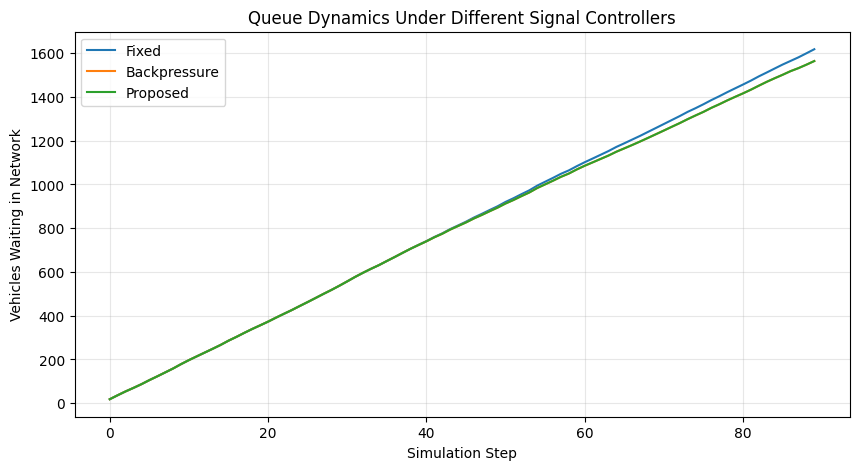

In [153]:
plt.figure(figsize=(10, 5))
for result in results:
    plt.plot(result["queue_history"], label=result["controller"].title())

plt.xlabel("Simulation Step")
plt.ylabel("Vehicles Waiting in Network")
plt.title("Queue Dynamics Under Different Signal Controllers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

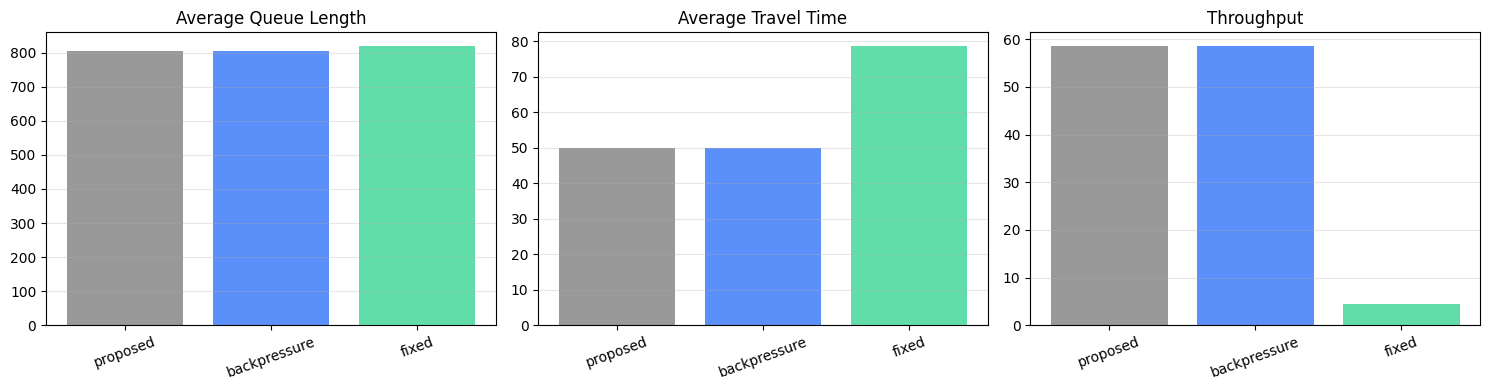

In [154]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_columns = [
    ("Average Queue Length", "Average Queue Length"),
    ("Average Travel Time", "Average Travel Time"),
    ("Throughput", "Throughput"),
]

for ax, (column, title) in zip(axes, plot_columns):
    ax.bar(metrics_df["Controller"], metrics_df[column], color=["#999999", "#5B8FF9", "#61DDAA"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
alpha_values = np.round(np.linspace(0.0, 1.0, 11), 2)
sweep_rows = []

for alpha in alpha_values:
    beta = float(np.round(1.0 - alpha, 2))
    sweep_results, sweep_metrics = evaluate_controllers_over_trials(
        graph=G,
        route_bank=route_bank,
        controllers=["proposed"],
        num_trials=NUM_TRIALS,
        base_seed=RANDOM_SEED,
        alpha=float(alpha),
        beta=beta,
        arrival_rate=ARRIVAL_RATE,
        simulation_steps=SIMULATION_STEPS,
        show_progress=False,
    )

    proposed_row = sweep_metrics.iloc[0]
    sweep_rows.append(
        {
            "alpha": float(alpha),
            "beta": beta,
            "avg_queue": float(proposed_row["Average Queue Length"]),
            "avg_travel_time": float(proposed_row["Average Travel Time"]),
            "throughput": float(proposed_row["Throughput"]),
            "completion_ratio": float(proposed_row["Completion Ratio"]),
        }
    )
    print(f"Completed alpha={alpha:.2f}, beta={beta:.2f}")

alpha_beta_df = pd.DataFrame(sweep_rows).sort_values("alpha").reset_index(drop=True)
alpha_beta_df

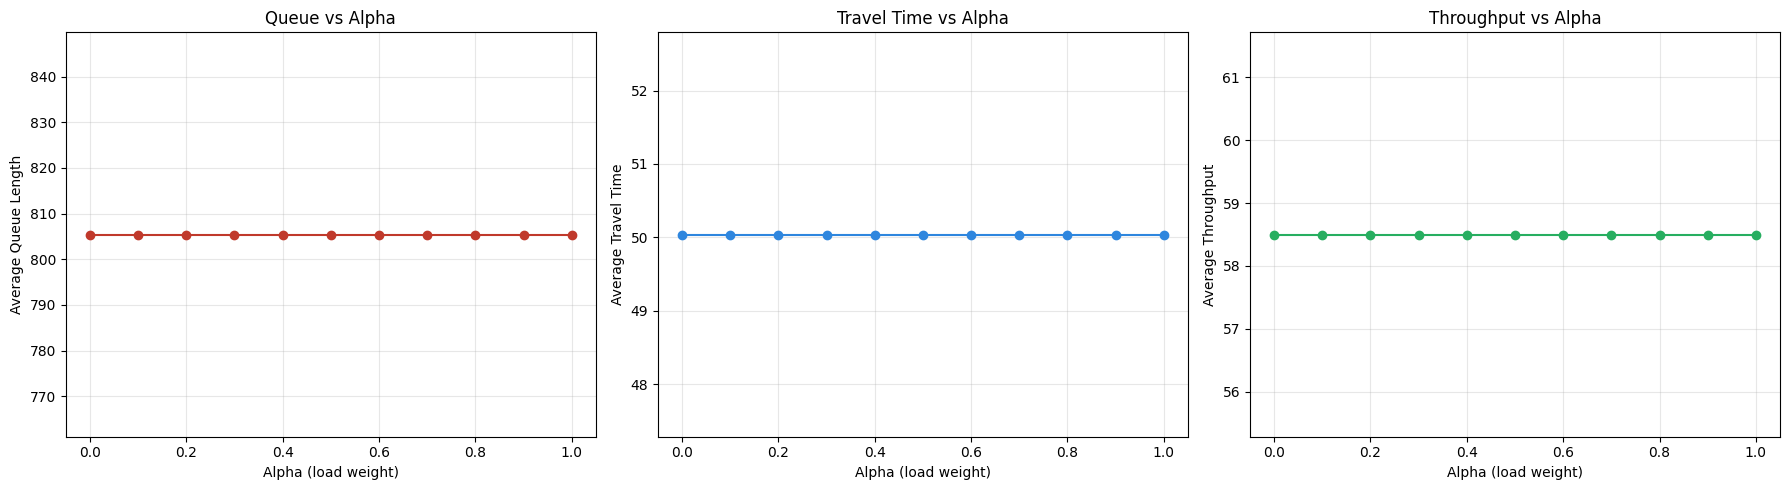

Best by throughput: alpha=0.00, beta=1.00, throughput=58.5, avg_queue=805.41


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(alpha_beta_df["alpha"], alpha_beta_df["avg_queue"], marker="o", color="#c0392b")
axes[0].set_xlabel("Alpha (load weight)")
axes[0].set_ylabel("Average Queue Length")
axes[0].set_title("Queue vs Alpha")
axes[0].grid(alpha=0.3)

axes[1].plot(alpha_beta_df["alpha"], alpha_beta_df["avg_travel_time"], marker="o", color="#2e86de")
axes[1].set_xlabel("Alpha (load weight)")
axes[1].set_ylabel("Average Travel Time")
axes[1].set_title("Travel Time vs Alpha")
axes[1].grid(alpha=0.3)

axes[2].plot(alpha_beta_df["alpha"], alpha_beta_df["throughput"], marker="o", color="#27ae60")
axes[2].set_xlabel("Alpha (load weight)")
axes[2].set_ylabel("Average Throughput")
axes[2].set_title("Throughput vs Alpha")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_throughput_idx = alpha_beta_df["throughput"].idxmax()
best_tp = alpha_beta_df.loc[best_throughput_idx]

print(
    f"Best by throughput: alpha={best_tp['alpha']:.2f}, beta={best_tp['beta']:.2f}, "
    f"throughput={best_tp['throughput']:.1f}, avg_queue={best_tp['avg_queue']:.2f}"
)

In [ ]:
top_nodes = sorted(
    G.nodes(data=True),
    key=lambda item: item[1].get("betweenness_norm", 0.0),
    reverse=True,
 )[:10]

centrality_df = pd.DataFrame(
    [
        {
            "node": node,
            "betweenness_norm": round(data.get("betweenness_norm", 0.0), 4),
            "in_degree": G.in_degree(node),
            "out_degree": G.out_degree(node),
        }
        for node, data in top_nodes
    ]
 )

centrality_df

,node,betweenness_norm,in_degree,out_degree
0,11505841146,1.0000,2,2
1,858975058,1.0000,2,2
2,21279528,0.8988,4,4
3,196400,0.8405,3,3
4,11505438330,0.8403,2,2
5,11505438295,0.8403,2,2
6,1745361197,0.8403,3,3
7,1745361160,0.8403,3,3
8,11505438328,0.8402,2,2
9,1439230027,0.8401,2,2


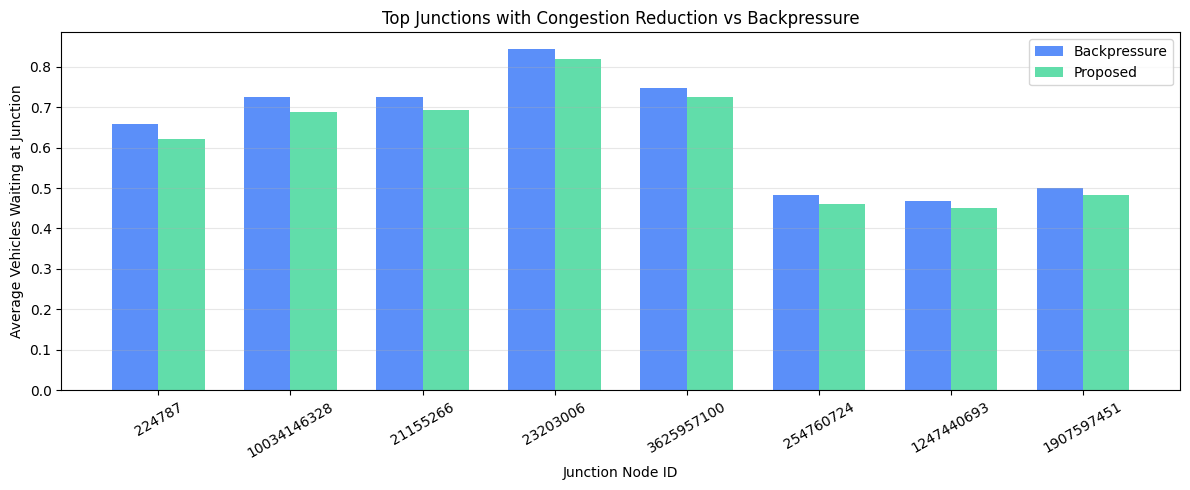

In [ ]:
plot_df = top_junction_improvements.head(8).copy()
plot_df["node"] = plot_df["node"].astype(str)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(
    x - width / 2,
    plot_df["backpressure_avg_queue"],
    width=width,
    label="Backpressure",
    color="#5B8FF9",
)
plt.bar(
    x + width / 2,
    plot_df["proposed_avg_queue"],
    width=width,
    label="Proposed",
    color="#61DDAA",
)
plt.xticks(x, plot_df["node"], rotation=30)
plt.ylabel("Average Vehicles Waiting at Junction")
plt.xlabel("Junction Node ID")
plt.title("Top Junctions with Congestion Reduction vs Backpressure")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
presentation_df = top_junction_improvements[[
    "node",
    "backpressure_avg_queue",
    "proposed_avg_queue",
    "reduction_vs_backpressure",
]].copy()

for column in [
    "backpressure_avg_queue",
    "proposed_avg_queue",
    "reduction_vs_backpressure",
]:
    presentation_df[column] = presentation_df[column].round(2)

presentation_df.head(5)

,node,backpressure_avg_queue,proposed_avg_queue,reduction_vs_backpressure
2618,224787,0.66,0.62,0.04
125580,10034146328,0.73,0.69,0.04
12100,21155266,0.73,0.69,0.03
15232,23203006,0.84,0.82,0.02
110540,3625957100,0.75,0.72,0.02


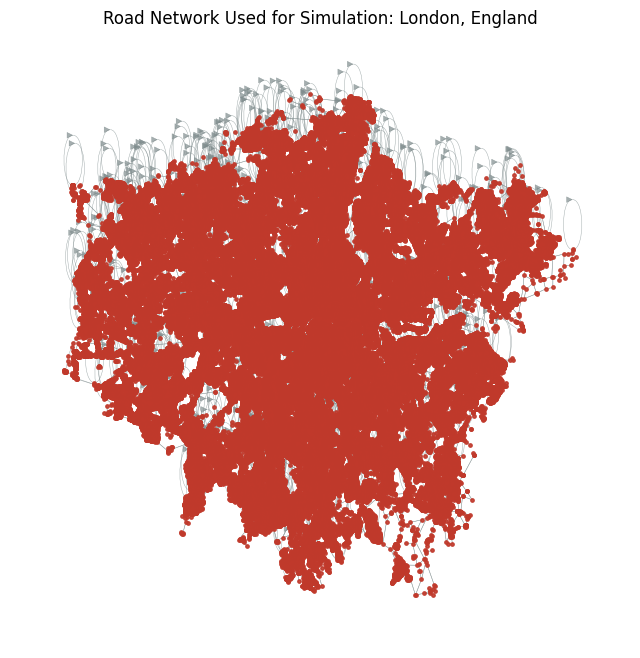

In [ ]:
positions = {
    node: (data["x"], data["y"])
    for node, data in G.nodes(data=True)
}

fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_edges(
    G,
    pos=positions,
    ax=ax,
    edge_color="#7f8c8d",
    width=0.35,
    alpha=0.7,
    arrows=False,
)
nx.draw_networkx_nodes(
    G,
    pos=positions,
    ax=ax,
    node_size=6,
    node_color="#c0392b",
    alpha=0.9,
)
ax.set_title(f"Road Network Used for Simulation: {PLACE}")
ax.set_axis_off()
plt.show()